In [1]:
import itertools 
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment

from visualization import (
    bulk_vs_singlecell_matrix_viz,
    loop_heatmap_plots_real_data,
    super_plot_heatmaps_real_data,
    barplot_matches_nonmatches_na,
 )
from accuracy_functions import load_expected_matches_real_data, find_mismatches_real_data
from analysis_shared_functions import (
    parse_heatmap_matrix_hysys,
    parse_heatmap_matrix_crosscheckfingerprints,
)

In [2]:
DATA_PATH = "../../data/output_data/" # Path to the directory containing the data files
FIGURES_PATH = "../../data/figures/" # Path to the directory where the figures will be saved

In [3]:
# Generally all the combinations of these parameters are present in the data, 
# except for BAMixChecker which only has results for read depth 0.
# And occassionally, tools may be missing results because they failed to run for certain combinations of parameters.
tools = ["CrosscheckFingerprints", "HYSYS", "NGSCheckmate", "Vireo"]
read_depths_mod1 = [0, 10, 20, 30]
read_depths_mod2 = [0, 10, 20, 30]
datasets = ["hgsoc", "hgsoc-new", "high_grade_glioma", "low_grade_glioma", "wilms_tumor"]

# Sample similarity heatmaps

Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth bulk_0_single-cell_0...
Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth bulk_10_single-cell_10...
Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth bulk_20_single-cell_20...
Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth bulk_30_single-cell_30...
Processing tool HYSYS, dataset low_grade_glioma, read depth bulk_0_single-cell_0...
Processing tool HYSYS, dataset low_grade_glioma, read depth bulk_10_single-cell_10...
Processing tool HYSYS, dataset low_grade_glioma, read depth bulk_20_single-cell_20...
Processing tool HYSYS, dataset low_grade_glioma, read depth bulk_30_single-cell_30...
Processing tool NGSCheckmate, dataset low_grade_glioma, read depth bulk_0_single-cell_0...
Processing tool NGSCheckmate, dataset low_grade_glioma, read depth bulk_10_single-cell_10...
Processing tool NGSCheckmate, dataset low_grade_glioma, read dep

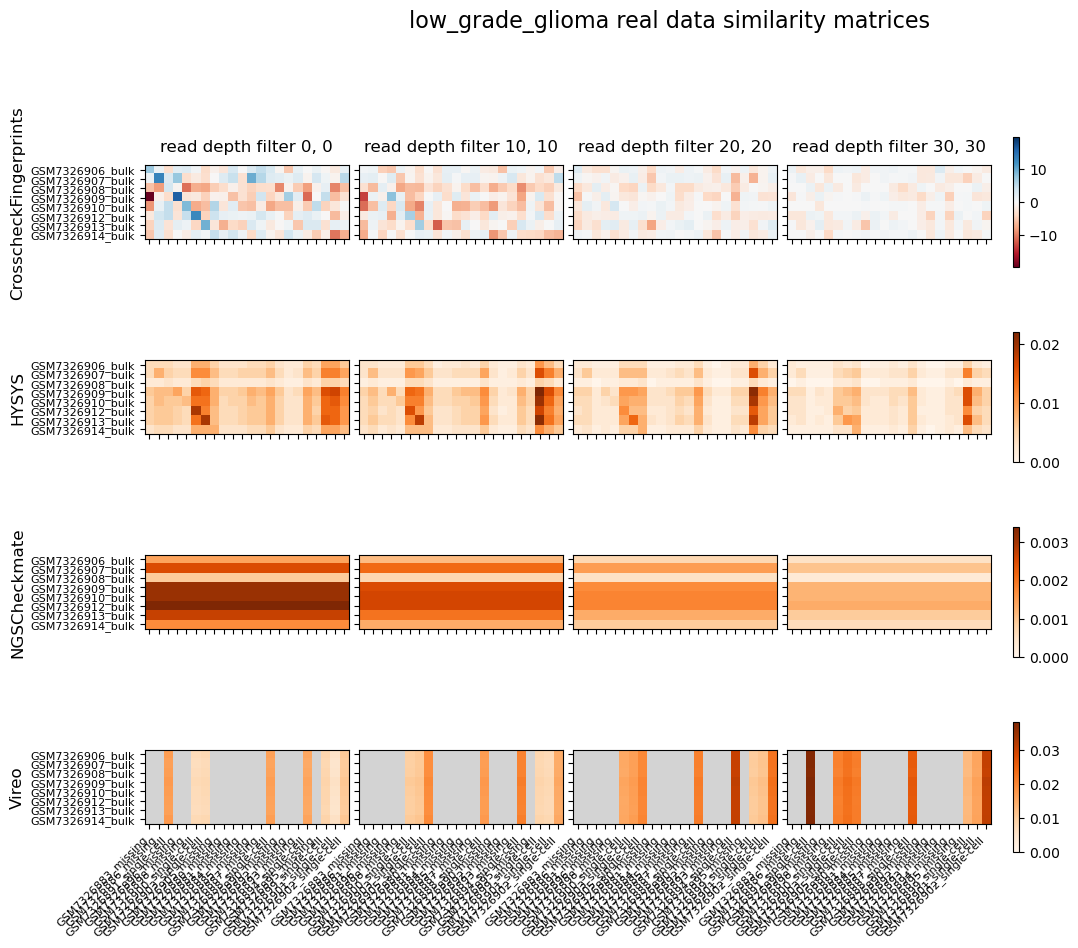

In [19]:
super_plot_heatmaps_real_data(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    tools=tools,
    dataset="low_grade_glioma",
    read_depths_mod1=read_depths_mod1,
    read_depths_mod2=read_depths_mod2,
    mod1="bulk",
    mod2="single-cell",
    remove_missing_data=True,
    save_fig=True,
)

In [3]:
# To plot an individual heatmap instead use this function
bulk_vs_singlecell_matrix_viz(
    DATA_PATH=DATA_PATH,
    pseudobulk=False,
    tool="CrosscheckFingerprints",
    dataset="hgsoc-new",
    ncells="null",
    rd_mod1=0,
    rd_mod2=0,
    mod1="bulk_diss_polyA",
    mod2="pooled_single_cell",
    save_fig=True,
    FIGURES_PATH=FIGURES_PATH,
)

Processing tool CrosscheckFingerprints, dataset hgsoc-new, read depth bulk_diss_polyA_0_pooled_single_cell_0...


IndexError: list index out of range

In [ ]:
from analysis_shared_functions import load_heatmap_data, order_matrix_by_expected_matches
matrix_df = load_heatmap_data(
        DATA_PATH, False, "CrosscheckFingerprints", "hgsoc-new", "null", "bulk_diss_polyA_0_pooled_single_cell_0", "bulk_diss_polyA", "pooled_single_cell"
    )

Processing tool CrosscheckFingerprints, dataset hgsoc-new, read depth 0...


In [5]:
matrix_df

,HGSOC-2018_bulk_chunk_ribo,HGSOC-2023_bulk_chunk_ribo,HGSOC-2094_bulk_chunk_ribo,HGSOC-2126_bulk_chunk_ribo,HGSOC-2129_bulk_chunk_ribo,HGSOC-2186_bulk_chunk_ribo,HGSOC-2202_bulk_chunk_ribo,HGSOC-2209_bulk_chunk_ribo,HGSOC-2216_bulk_chunk_ribo,HGSOC-2221_bulk_chunk_ribo,...,HGSOC-2408_bulk_diss_polyA,HGSOC-2416_bulk_diss_polyA,HGSOC-2423_bulk_diss_polyA,HGSOC-2455_bulk_diss_polyA,HGSOC-2460_bulk_diss_polyA,HGSOC-2466_bulk_diss_polyA,HGSOC-2477_bulk_diss_polyA,HGSOC-2483_bulk_diss_polyA,HGSOC-2514_bulk_diss_polyA,HGSOC-2526_bulk_diss_polyA
LEFT_SAMPLE,,,,,,,,,,,,,,,,,,,,,
HGSOC-2018_bulk_chunk_ribo,393.032277,-97.780207,-114.146281,-71.000810,-54.431121,-86.936601,-95.274667,-94.537169,-74.043438,-113.100578,...,-42.390117,-30.655281,-36.542538,-18.024149,-27.074325,-23.943656,-90.380096,-49.415399,-43.843921,-27.188235
HGSOC-2023_bulk_chunk_ribo,-97.780207,385.013053,-132.142530,-71.434135,-59.159204,-71.072356,-88.445418,-81.485328,-98.875114,-101.845400,...,-51.133915,-35.103306,-51.069745,-25.444727,-47.575130,-34.420294,-78.970439,-39.430843,-47.928020,-40.822741
HGSOC-2094_bulk_chunk_ribo,-114.146281,-132.142530,337.803067,-78.264740,-54.047765,-63.075865,-65.215290,-50.570442,-128.006769,-112.558436,...,-42.382779,-30.695387,-38.634395,-30.899418,-38.197791,-31.925852,-88.800344,-24.455072,-33.089785,-42.160665
HGSOC-2126_bulk_chunk_ribo,-71.000810,-71.434135,-78.264740,315.904736,-35.935220,-60.099895,-67.561908,-37.352543,-42.351843,-93.527706,...,-5.713769,-7.969152,-13.499095,-33.648922,-33.961770,-22.983549,-66.016051,-44.015858,-25.548945,-31.283508
HGSOC-2129_bulk_chunk_ribo,-54.431121,-59.159204,-54.047765,-35.935220,356.604685,-56.915111,-43.059260,-43.878240,-55.337167,-41.365370,...,-25.914023,-23.308008,-28.358691,-17.230669,-35.898326,-24.546586,-40.342671,-25.528357,-27.863582,-20.712871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HGSOC-2466_bulk_diss_polyA,-23.943656,-34.420294,-31.925852,-22.983549,-24.546586,-29.399391,-30.516245,-35.785017,-31.465703,-34.003277,...,-35.099841,-21.667003,-23.350100,-23.495817,-25.773176,67.196542,-29.668770,-33.366439,-25.110989,-23.434093
HGSOC-2477_bulk_diss_polyA,-90.380096,-78.970439,-88.800344,-66.016051,-40.342671,-58.552024,-55.431170,-87.721051,-70.346432,-97.958454,...,-42.303627,-48.752633,-48.665305,-44.124816,-44.992439,-29.668770,514.763354,-60.967869,-34.633342,-36.875647
HGSOC-2483_bulk_diss_polyA,-49.415399,-39.430843,-24.455072,-44.015858,-25.528357,-34.881480,-33.520801,-49.352900,-43.764585,-49.241432,...,-41.651147,-24.401585,-46.908388,-12.212785,-35.586440,-33.366439,-60.967869,175.133382,-43.713897,-22.830364


In [6]:
expected_matches = load_expected_matches_real_data(DATA_PATH, "hgsoc")
sub_matrix = order_matrix_by_expected_matches(
    matrix_df,
    expected_matches,
    "bulk_dissociated_polyA",
    "single-cell",
)

In [7]:
sub_matrix

,2251_single_cell_single-cell,2267_single_cell_single-cell,2283_single_cell_single-cell,2293_single_cell_single-cell,2380_single_cell_single-cell,2428_single_cell_single-cell,2467_single_cell_single-cell,2497_single_cell_single-cell
2251_bulk_dissociated_polyA_bulk_dissociated_polyA,0.207982,0.209938,0.207206,0.208431,0.210979,0.203666,0.211123,0.210500
2267_bulk_dissociated_polyA_bulk_dissociated_polyA,0.195956,0.197696,0.194957,0.196005,0.198737,0.191427,0.198870,0.198297
2283_bulk_dissociated_polyA_bulk_dissociated_polyA,0.184208,0.185949,0.183134,0.184443,0.186993,0.179694,0.187120,0.186532
2293_bulk_dissociated_polyA_bulk_dissociated_polyA,0.187937,0.189523,0.186973,0.188213,0.190727,0.183413,0.190868,0.190296
2380_bulk_dissociated_polyA_bulk_dissociated_polyA,0.215890,0.217668,0.214951,0.216136,0.218530,0.211388,0.218854,0.218208
2428_bulk_dissociated_polyA_bulk_dissociated_polyA,0.174186,0.175920,0.173197,0.174462,0.176937,0.169559,0.177101,0.176489
2467_bulk_dissociated_polyA_bulk_dissociated_polyA,0.200770,0.202593,0.199840,0.201058,0.203580,0.196262,0.203493,0.203109
2497_bulk_dissociated_polyA_bulk_dissociated_polyA,0.248274,0.250037,0.247275,0.248508,0.250999,0.243737,0.251161,0.250361


In [ ]:
# To plot multiple individual heatmaps use this function
loop_heatmap_plots_real_data(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    tools=["Vireo", "HYSYS", "CrosscheckFingerprints"],
    datasets=["hgsoc"],
    read_depths_mod1=[3],
    read_depths_mod2=[25],
    mod1="bulk_dissociated_polyA",
    mod2="single-cell",
)

Processing tool Vireo, dataset hgsoc, read depth 3_25...
Processing tool HYSYS, dataset hgsoc, read depth 3_25...
Processing tool CrosscheckFingerprints, dataset hgsoc, read depth 3_25...


# Comparison of inferred and expected sample matches

In [5]:
# # Plot how many matches, non-matches, and NAs there are for each tool across read depths for a given dataset
# barplot_matches_nonmatches_na(
#     DATA_PATH=DATA_PATH, 
#     tools=tools, 
#     dataset="high_grade_glioma", 
#     read_depths=read_depths, 
#     mod1="bulk", 
#     mod2="single-cell", 
#     save_fig=False, 
#     FIGURES_PATH=FIGURES_PATH
#     )

In [30]:
merged_df = find_mismatches_real_data(
    DATA_PATH=DATA_PATH, 
    tool="CrosscheckFingerprints", 
    dataset="wilms_tumor", 
    rd1=0, 
    rd2=0,
    mod1="bulk", 
    mod2="single-nucleus"
)
merged_df


Processing tool CrosscheckFingerprints, dataset wilms_tumor, read depth bulk=0, single-nucleus=0...


,single-nucleus sample id,bulk sample id,sample_id_0,sample_id_1,modality_0,modality_1,match_status
0,NaN,NaN,SJWLM018918_D1,GSM6025606,bulk,single-nucleus,right_only
1,NaN,NaN,SJWLM018918_D1,GSM6025607,bulk,single-nucleus,right_only
2,NaN,NaN,SJWLM018918_D1,GSM6025608,bulk,single-nucleus,right_only
3,NaN,NaN,SJWLM018918_D1,GSM6025626,bulk,single-nucleus,right_only
4,GSM6025627,SJWLM018918_D1,SJWLM018918_D1,GSM6025627,bulk,single-nucleus,both
...,...,...,...,...,...,...,...
254,GSM6025626,SJWLM071564_D1,SJWLM071564_D1,GSM6025626,bulk,single-nucleus,both
255,NaN,NaN,SJWLM071564_D1,GSM6025628,bulk,single-nucleus,right_only
256,NaN,NaN,SJWLM071564_D1,GSM6025630,bulk,single-nucleus,right_only
257,NaN,NaN,SJWLM071564_D1,GSM6025631,bulk,single-nucleus,right_only


In [38]:
merged_df[merged_df["single-nucleus sample id"].str.contains("623", na=False)]

,single-nucleus sample id,bulk sample id,sample_id_0,sample_id_1,modality_0,modality_1,match_status
63,GSM6025623,SJWLM051026_D2,SJWLM051026_D2,GSM6025623,bulk,single-nucleus,both


In [33]:
merged_df[merged_df["match_status"] == "left_only"]

,single-nucleus sample id,bulk sample id,sample_id_0,sample_id_1,modality_0,modality_1,match_status
18,GSM6025611,SJWLM030545_D1,NaN,NaN,NaN,NaN,left_only
64,GSM6025624,SJWLM051026_D2,NaN,NaN,NaN,NaN,left_only
69,GSM6025619,SJWLM056073_D1,NaN,NaN,NaN,NaN,left_only
129,GSM6025608,SJWLM059679_D1,NaN,NaN,NaN,NaN,left_only
168,GSM6025616,SJWLM071552_D1,NaN,NaN,NaN,NaN,left_only
258,GSM6025643,<NA>,NaN,NaN,NaN,NaN,left_only


In [29]:
merged_df["bulk sample id"].nunique()

37